<a href="https://colab.research.google.com/github/valentinroldan521-cpu/Modelizado-IA/blob/main/Valentin_Roldan_Unidad_3_RRNN_multicapa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica: Clasificación de Ropa con Fashion MNIST
**Consigna:** El objetivo de este ejercicio es diseñar, entrenar y evaluar una red neuronal profunda (MLP) capaz de clasificar imágenes de 28x28 píxeles en 10 categorías de vestimenta. Deberás completar las secciones de código indicadas para que el modelo logre una precisión aceptable en el set de prueba.

## 1. Carga de Datos y Preprocesamiento
El primer paso es normalizar las imágenes. Como las redes neuronales son calculadoras de promedios ponderados, es vital que las entradas estén en la misma escala (generalmente entre 0 y 1) para evitar que magnitudes grandes dominen el aprendizaje.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Cargamos el dataset de ropa
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Etiquetas de las 10 categorías
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# AYUDA: Dividir los arreglos por 255.0 para normalizar los píxeles al rango [0, 1]
train_images = train_images / 255.0  # COMPLETAR AQUÍ
test_images = test_images / 255.0 # COMPLETAR AQUÍ

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 2. Definición de la Arquitectura (MLP)
Configurar las capas de la red. Recirdar que la Capa de Entrada debe **"aplanar"** la matriz de 28x28. En las Capas Ocultas, utilizamos la función **ReLU** por su eficiencia para transmitir señales positivas . Finalmente, la Capa de Salida debe tener 10 neuronas (una por cada prenda) y usar **Softmax** para entregar una distribución de probabilidad que sume 1 .

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def crear_modelo():
    model = models.Sequential([
        # Capa de Entrada: Definición moderna usando Input
        layers.Input(shape=(28, 28)),
        layers.Flatten(),

        # Capa densa 1
        layers.Dense(128, activation='relu'),

        # Capa densa 2
        layers.Dense(64, activation='relu'),

        # Capa de Salida: 10 neuronas (una por clase)
        # Utilizamos 'softmax' para obtener probabilidades
        layers.Dense(10, activation='softmax')
    ])
    return model

# A partir de aca se instancia el modelo
model = crear_modelo()

# utilizamos model.summary para mostrar la estructura
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Compilación y Entrenamiento
Para que la red aprenda, aplicamos el algoritmo de Backpropagation. Configuraremos el optimizador para ajustar los pesos y una función de pérdida que mida la discrepancia entre la predicción y la realidad

In [ ]:
# 1. Compilación (se mantiene igual, está correcta)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Configuración de Early Stopping (Corregido el monitor)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',     #: 'val_loss' con guion bajo
    patience=5,             # Número de épocas a esperar tras no haber mejora
    restore_best_weights=True # Crucial para quedarse con el mejor modelo, no el último
)

# 3. Entrenamiento
history = model.fit(
    train_images,
    train_labels,
    epochs=30,
    validation_split=0.2, # Reservamos el 20% para que EarlyStopping pueda "mirar"
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8952 - loss: 0.2840 - val_accuracy: 0.8806 - val_loss: 0.3344
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8985 - loss: 0.2712 - val_accuracy: 0.8805 - val_loss: 0.3314
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9047 - loss: 0.2565 - val_accuracy: 0.8792 - val_loss: 0.3421
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9063 - loss: 0.2487 - val_accuracy: 0.8877 - val_loss: 0.3228
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9105 - loss: 0.2374 - val_accuracy: 0.8922 - val_loss: 0.3180
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9140 - loss: 0.2289 - val_accuracy: 0.8849 - val_loss: 0.3350
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9164 - loss: 0.2203 - val_accuracy: 0.8955 - val_loss: 0.3160
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9201 - loss: 0.2139 

## 4. Evaluación y Predicción
Una vez entrenada, es fundamental evaluar el modelo con datos que nunca ha visto (set de prueba) para verificar su capacidad de generalización y asegurar que no solo memorizó los ejemplos de entrenamiento

313/313 - 1s - 2ms/step - accuracy: 0.8839 - loss: 0.3434

Precisión en el set de prueba: 88.39%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


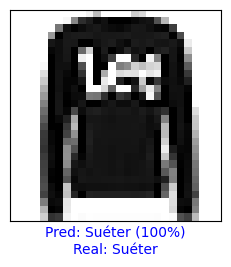

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Se evalua el modelo
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nPrecisión en el set de prueba: {test_acc:.2%}')

#Se realizan las predicciones
predictions = model.predict(test_images)

# Definimos etiquetas (Fashion MNIST) si no las tienes:
class_names = ['Camiseta', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

# Visualización de una predicción individual
n = 1 # Índice de la imagen que quieres ver
plt.figure(figsize=(6,3))

# Imagen
plt.subplot(1, 2, 1)
plt.grid(False)
plt.xticks([])
plt.yticks([])
plt.imshow(test_images[n], cmap=plt.cm.binary)

predicted_label = np.argmax(predictions[n])
true_label = test_labels[n]
color = 'blue' if predicted_label == true_label else 'red'

plt.xlabel(f"Pred: {class_names[predicted_label]} ({100*np.max(predictions[n]):2.0f}%)\nReal: {class_names[true_label]}",
           color=color)
plt.show()

## Guía:
- **Normalización:** Si olvidas este paso, notarás que el error (loss) baja muy lentamente o el modelo no converge.
- **Activaciones:** ¿Qué sucede si usas una función lineal en lugar de ReLU en las capas ocultas? La red perdería su capacidad de detectar patrones complejos.
- **Softmax:** Observa cómo las 10 salidas de la última capa compiten entre sí; la prenda con el valor más alto es la elegida por el sistema .